# Comparing Artifacts: California (GBD 2019) vs USA (GBD 2023)

This notebook compares two artifacts used in the vivarium CVD simulation:

1. **California, GBD 2019** (`california.hdf`): The original artifact built from
   GBD 2019 data for California, using the previous version of the pipeline.
2. **USA, GBD 2023** (`united_states_of_america.hdf`): A national-level artifact
   built from GBD 2023 data, using the updated vivarium 4 pipeline.

Because these come from different GBD rounds (2019 vs 2023) and different
locations (California vs USA), we expect meaningful differences. The goal
is to verify that the new artifact is structurally sound and that the
values are in a plausible range relative to the older artifact.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ARTIFACT_DIR = Path('../src/vivarium_nih_us_cvd/artifacts')
CA_PATH = ARTIFACT_DIR / 'california.hdf'        # GBD 2019, California
USA_PATH = ARTIFACT_DIR / 'united_states_of_america.hdf'  # GBD 2023, USA

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## Key Differences Between the Artifacts

| Property | California (GBD 2019) | USA (GBD 2023) |
|---|---|---|
| Location | California | United States of America |
| GBD round | 2019 | 2023 |
| `year_start` in most keys | 2019 | 2023 |
| Number of draws (most keys) | 1000 | 250 |
| Age groups | 23 | 25 |

Because the year and age-bin indices differ, comparisons below merge
on **sex and age only** (dropping year columns) and use only
**age bins present in both** artifacts.

---
## Visual Comparison

In [2]:
# Check which artifacts are available
ca_exists = CA_PATH.exists()
usa_exists = USA_PATH.exists()

print(f'California (GBD 2019): {"FOUND" if ca_exists else "MISSING"} ({CA_PATH})')
print(f'USA (GBD 2023):        {"FOUND" if usa_exists else "MISSING"} ({USA_PATH})')

if not (ca_exists and usa_exists):
    print('\n*** Both artifacts must be present for comparison. ***')

California (GBD 2019): FOUND (../src/vivarium_nih_us_cvd/artifacts/california.hdf)
USA (GBD 2023):        FOUND (../src/vivarium_nih_us_cvd/artifacts/united_states_of_america.hdf)


### Key Inventory Comparison

In [3]:
with pd.HDFStore(str(CA_PATH), 'r') as s1, pd.HDFStore(str(USA_PATH), 'r') as s2:
    keys_ca = set(s1.keys())
    keys_usa = set(s2.keys())

print(f'California keys: {len(keys_ca)}')
print(f'USA keys:        {len(keys_usa)}')
print(f'\nIn California only: {keys_ca - keys_usa or "none"}')
print(f'In USA only:        {keys_usa - keys_ca or "none"}')

California keys: 54
USA keys:        54

In California only: none
In USA only:        none


### Population Structure Comparison

California total population: 39,872,033
USA total population:        335,414,198
Ratio (USA / CA):            8.4x


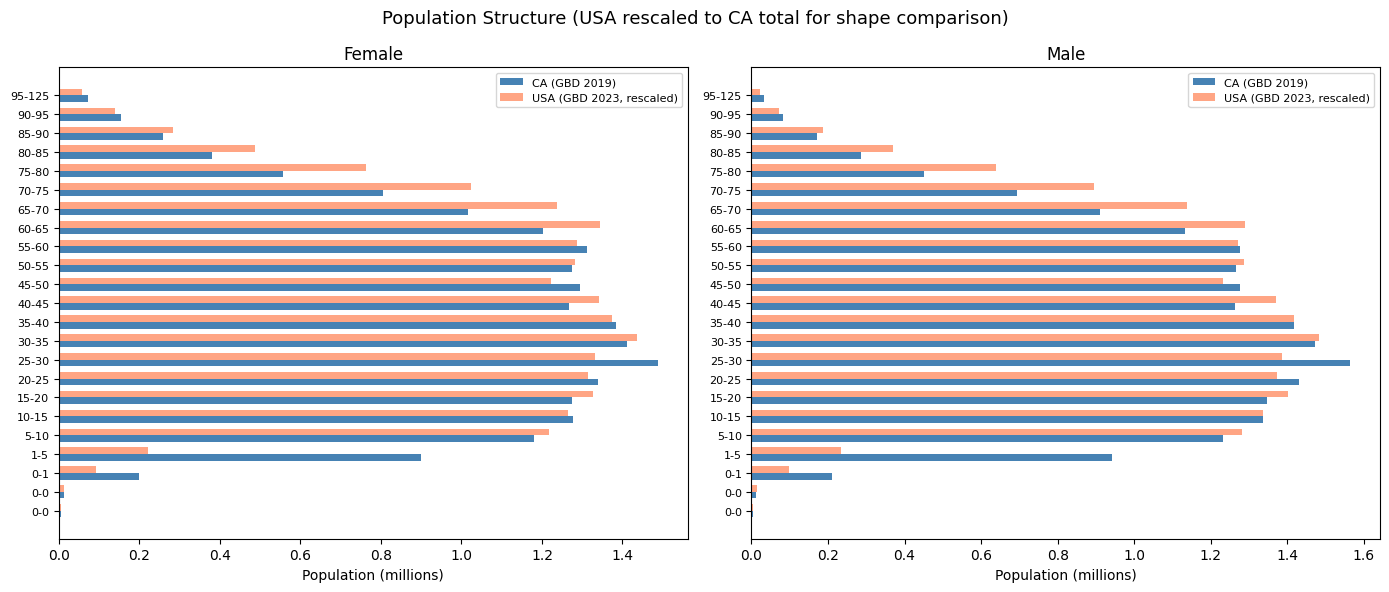

In [4]:
ca_pop = pd.read_hdf(CA_PATH, '/population/structure').reset_index()
usa_pop = pd.read_hdf(USA_PATH, '/population/structure').reset_index()
for df in [ca_pop, usa_pop]:
    for col in ['location', 'year_start', 'year_end']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

print(f'California total population: {ca_pop["value"].sum():,.0f}')
print(f'USA total population:        {usa_pop["value"].sum():,.0f}')
print(f'Ratio (USA / CA):            {usa_pop["value"].sum() / ca_pop["value"].sum():.1f}x')

# Find common age bins for plotting
common_ages = sorted(set(ca_pop['age_start']) & set(usa_pop['age_start']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for sex, ax in zip(['Female', 'Male'], axes):
    ca = ca_pop[(ca_pop['sex'] == sex) & (ca_pop['age_start'].isin(common_ages))].sort_values('age_start')
    us = usa_pop[(usa_pop['sex'] == sex) & (usa_pop['age_start'].isin(common_ages))].sort_values('age_start')
    ages = ca['age_start'].values
    width = 0.35
    x = np.arange(len(ages))
    # Normalize USA to CA scale for shape comparison
    ax.barh(x - width/2, ca['value']/1e6, width, label='CA (GBD 2019)', color='steelblue')
    ax.barh(x + width/2, us['value']/1e6 * (ca['value'].sum() / us['value'].sum()), width,
            label='USA (GBD 2023, rescaled)', color='coral', alpha=0.7)
    labels = [f"{int(a)}-{int(b)}" for a, b in zip(ca['age_start'], ca['age_end'])]
    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Population (millions)')
    ax.set_title(sex)
    ax.legend(fontsize=8)
fig.suptitle('Population Structure (USA rescaled to CA total for shape comparison)', fontsize=13)
plt.tight_layout()
plt.show()

### Disease Rate Comparisons

In [5]:
def load_rate(path, key, draw='draw_0'):
    """Load a rate from artifact and return as age-sex DataFrame.

    Drops year and location columns so that artifacts from different
    GBD rounds can be merged on sex + age only.
    """
    df = pd.read_hdf(path, key)
    if draw in df.columns:
        df = df[[draw]].rename(columns={draw: 'value'})
    df = df.reset_index()
    for col in ['year_start', 'year_end', 'location']:
        if col in df.columns:
            df = df.drop(columns=[col])
    return df


def compare_rates(key, title, ax):
    """Plot CA (GBD 2019) vs USA (GBD 2023) for a given key."""
    for label, path, marker, linestyle in [
        ('CA (GBD 2019)', CA_PATH, 'o', '--'),
        ('USA (GBD 2023)', USA_PATH, 's', '-'),
    ]:
        df = load_rate(path, key)
        for sex in ['Female', 'Male']:
            sub = df[(df['sex'] == sex) & (df['age_start'] >= 25)].sort_values('age_start')
            ax.plot(sub['age_start'], sub['value'],
                    label=f'{label} ({sex[0]})', marker=marker,
                    linestyle=linestyle,
                    color='#FF4040' if sex == 'Female' else '#8080FF',
                    linewidth=2 if 'CA' in label else 1.5,
                    alpha=0.9 if 'CA' in label else 0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Age')
    ax.set_ylabel('Rate')
    ax.legend(fontsize=7)
    ax.set_xlim(25, 100)

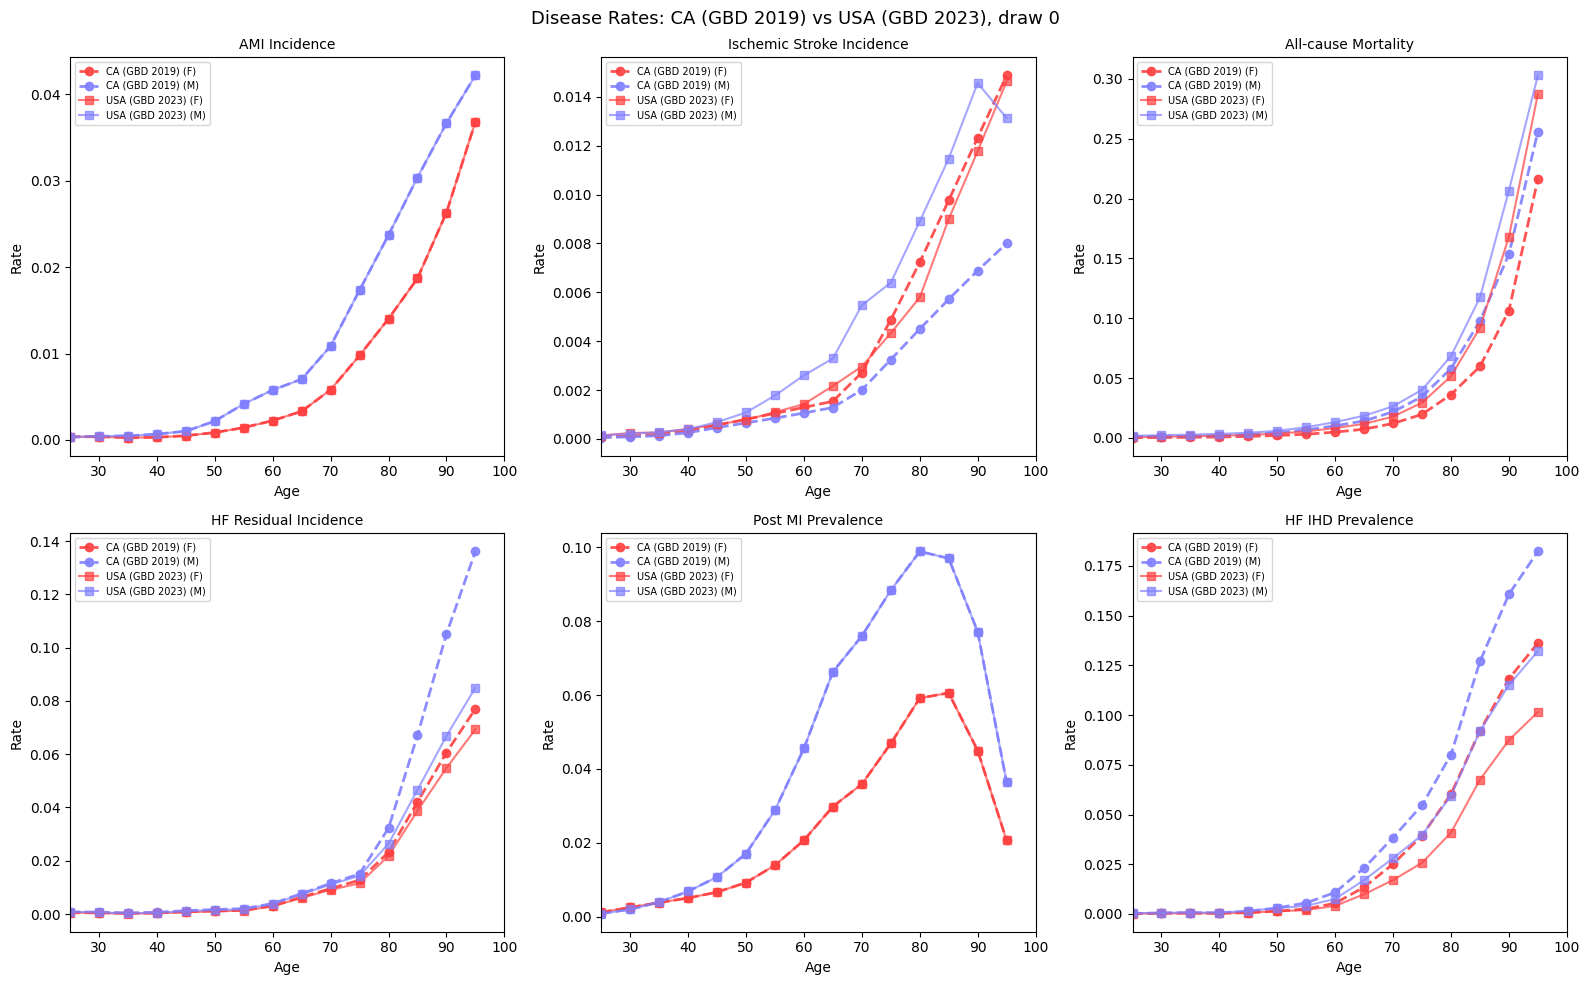

In [6]:
rate_keys = {
    'AMI Incidence': '/cause/acute_myocardial_infarction/incidence_rate',
    'Ischemic Stroke Incidence': '/cause/ischemic_stroke/incidence_rate',
    'All-cause Mortality': '/cause/all_causes/cause_specific_mortality_rate',
    'HF Residual Incidence': '/cause/heart_failure_residual/incidence_rate',
    'Post MI Prevalence': '/cause/post_myocardial_infarction/prevalence',
    'HF IHD Prevalence': '/cause/heart_failure_from_ischemic_heart_disease/prevalence',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (title, key) in zip(axes.flat, rate_keys.items()):
    compare_rates(key, title, ax)
fig.suptitle('Disease Rates: CA (GBD 2019) vs USA (GBD 2023), draw 0', fontsize=13)
plt.tight_layout()
plt.show()

### Risk Factor Exposure Comparisons

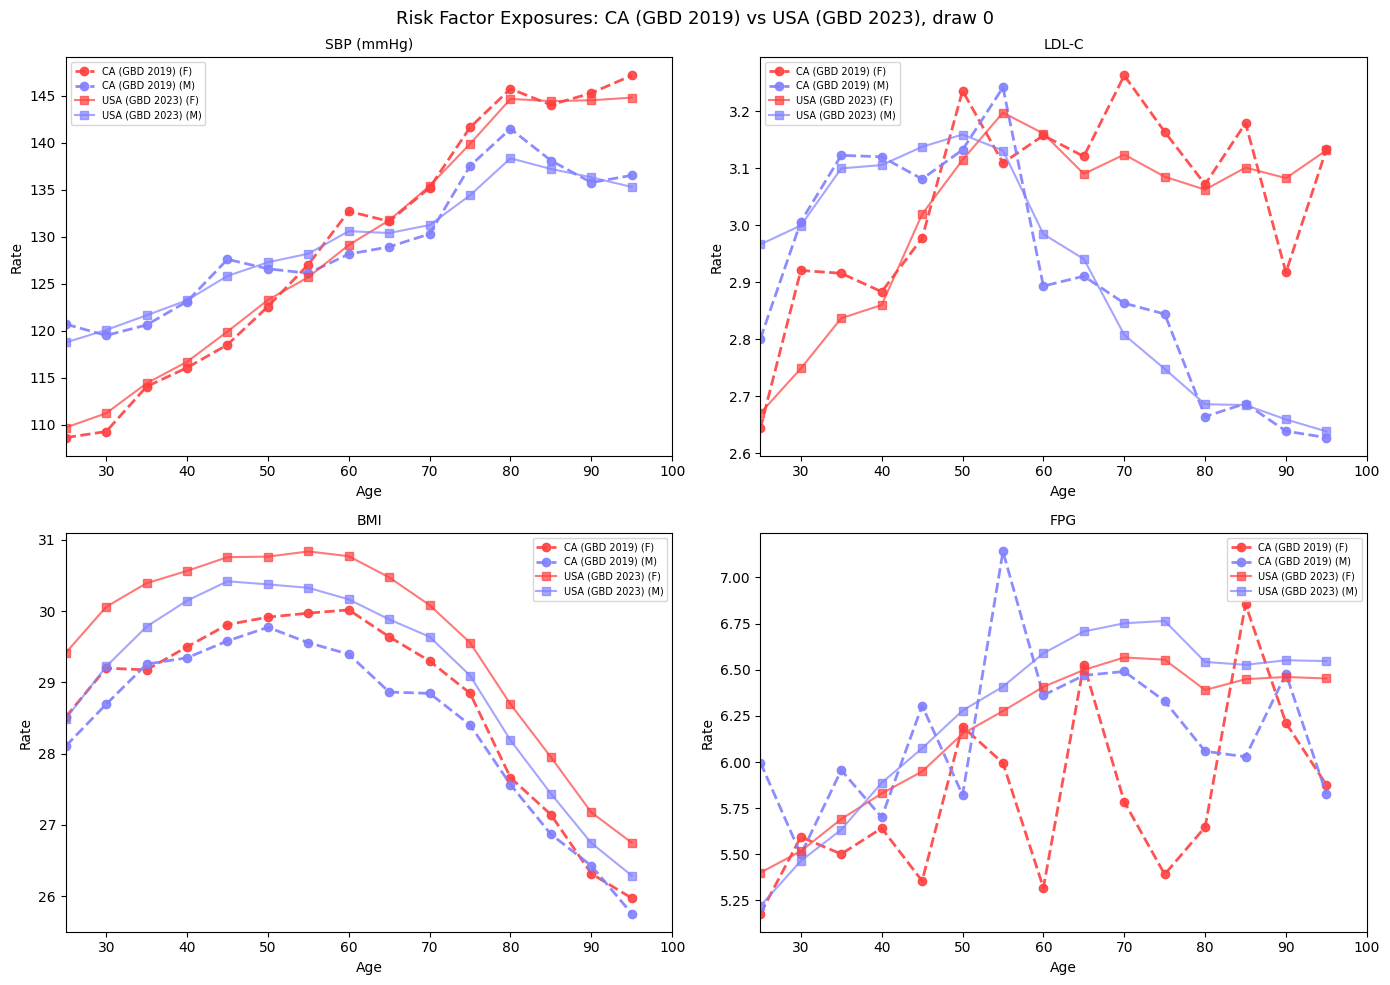

In [7]:
exposure_keys = {
    'SBP (mmHg)': '/risk_factor/high_systolic_blood_pressure/exposure',
    'LDL-C': '/risk_factor/high_ldl_cholesterol/exposure',
    'BMI': '/risk_factor/high_body_mass_index_in_adults/exposure',
    'FPG': '/risk_factor/high_fasting_plasma_glucose/exposure',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (title, key) in zip(axes.flat, exposure_keys.items()):
    compare_rates(key, title, ax)
fig.suptitle('Risk Factor Exposures: CA (GBD 2019) vs USA (GBD 2023), draw 0', fontsize=13)
plt.tight_layout()
plt.show()

### Joint PAF Comparisons

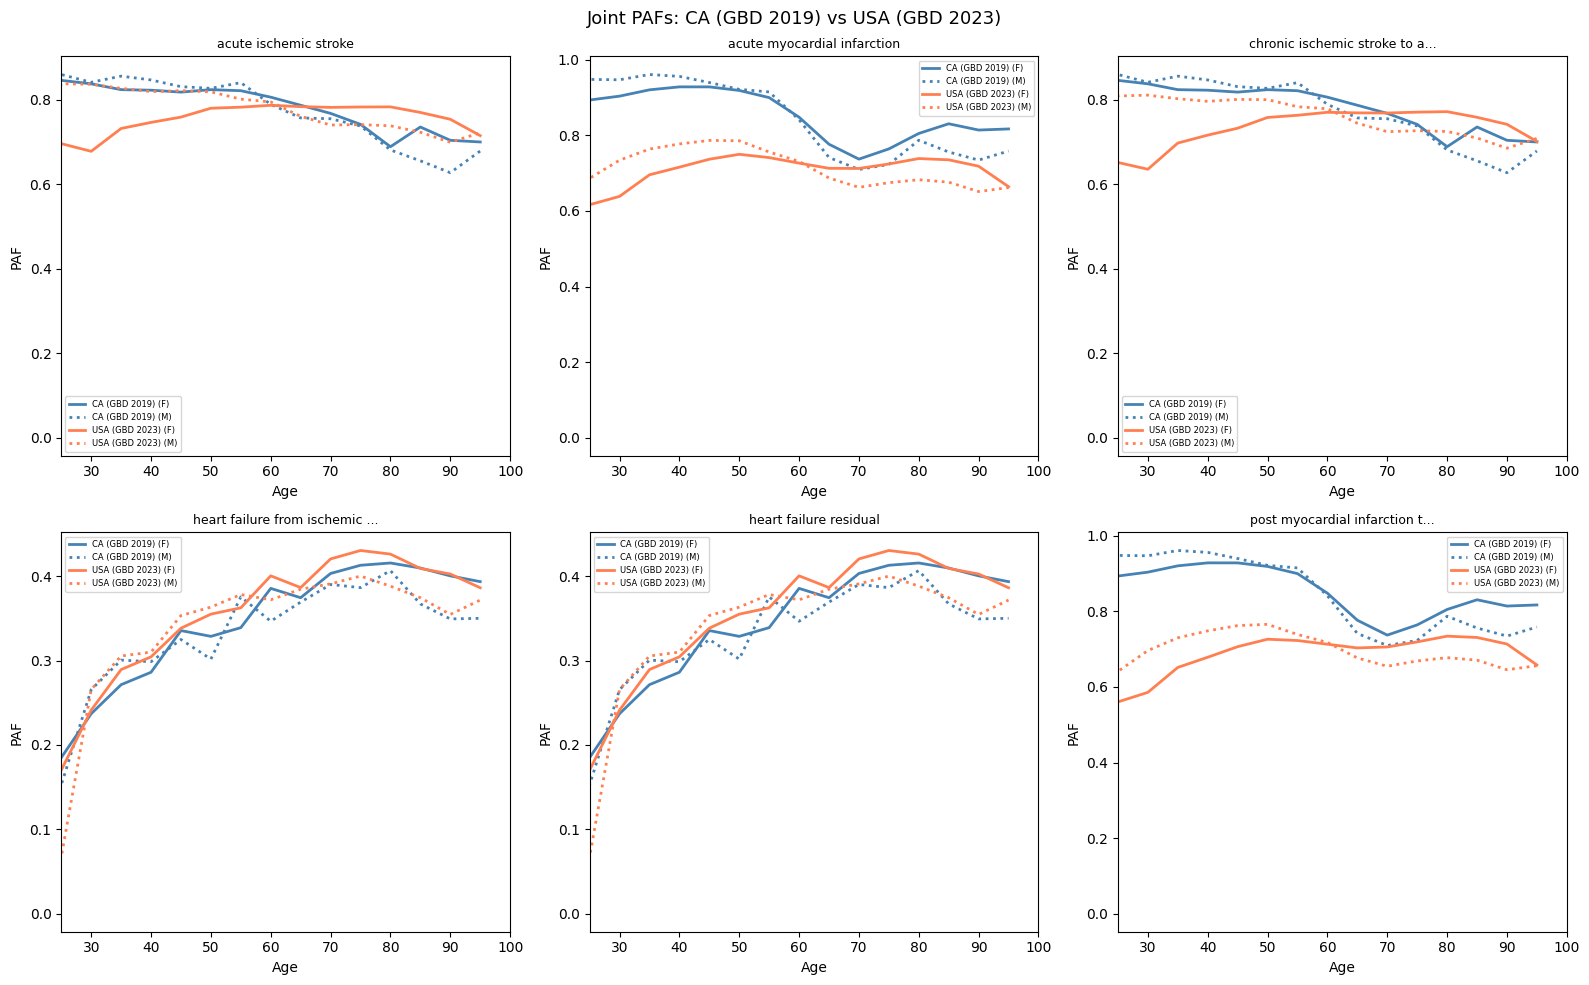

In [8]:
paf_key = '/risk_factor/joint_mediated_risks/population_attributable_fraction'

def _load_paf(path):
    """Load joint PAF, handling both draw-column and flat-value formats."""
    df = pd.read_hdf(path, paf_key)
    if 'value' in df.columns:
        # Flat format (USA) — already has 'value' column
        out = df if df.index.names == [None] else df.reset_index()
    else:
        # Draw format (CA) — take draw_0
        out = df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
    for col in ['year_start', 'year_end', 'location']:
        if col in out.columns:
            out = out.drop(columns=[col])
    return out

ca_pafs = _load_paf(CA_PATH)
usa_pafs = _load_paf(USA_PATH)

entities = sorted(ca_pafs['affected_entity'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, entity in zip(axes.flat, entities):
    for label, df, color, ls in [
        ('CA (GBD 2019)', ca_pafs, 'steelblue', '-'),
        ('USA (GBD 2023)', usa_pafs, 'coral', '--'),
    ]:
        for sex, marker_ls in [('Female', '-'), ('Male', ':')]:
            sub = df[(df['affected_entity'] == entity) & (df['sex'] == sex)]
            sub = sub.sort_values('age_start')
            ax.plot(sub['age_start'], sub['value'],
                    label=f'{label} ({sex[0]})',
                    color=color, linewidth=2, linestyle=marker_ls)
    short_name = entity.replace('_', ' ')
    if len(short_name) > 30:
        short_name = short_name[:28] + '...'
    ax.set_title(short_name, fontsize=9)
    ax.set_xlabel('Age')
    ax.set_ylabel('PAF')
    ax.legend(fontsize=6)
    ax.set_xlim(25, 100)

fig.suptitle('Joint PAFs: CA (GBD 2019) vs USA (GBD 2023)', fontsize=13)
plt.tight_layout()
plt.show()

### Quantitative Summary: Relative Differences

For keys where both artifacts share common age bins, compute
the relative difference on draw 0. Since these are different
locations and GBD rounds, large differences are expected.

In [9]:
summary_keys = {
    'AMI Incidence': '/cause/acute_myocardial_infarction/incidence_rate',
    'Stroke Incidence': '/cause/ischemic_stroke/incidence_rate',
    'ACMR': '/cause/all_causes/cause_specific_mortality_rate',
    'HF Residual Inc': '/cause/heart_failure_residual/incidence_rate',
    'SBP Exposure': '/risk_factor/high_systolic_blood_pressure/exposure',
    'LDL-C Exposure': '/risk_factor/high_ldl_cholesterol/exposure',
    'BMI Exposure': '/risk_factor/high_body_mass_index_in_adults/exposure',
    'FPG Exposure': '/risk_factor/high_fasting_plasma_glucose/exposure',
}

results = []
for name, key in summary_keys.items():
    ca = load_rate(CA_PATH, key)
    us = load_rate(USA_PATH, key)
    # Merge on sex + age only (year already dropped by load_rate)
    merge_cols = [c for c in ['sex', 'age_start', 'age_end']
                  if c in ca.columns and c in us.columns]
    merged = ca.merge(us, on=merge_cols, suffixes=('_ca', '_usa'))
    if len(merged) == 0:
        results.append({'Measure': name, 'Mean Rel Diff (%)': np.nan,
                        'Median Rel Diff (%)': np.nan, 'Max Abs Rel Diff (%)': np.nan,
                        'Cells Compared': 0})
        continue
    merged['rel_diff'] = ((merged['value_ca'] - merged['value_usa'])
                          / merged['value_usa'].replace(0, np.nan))
    results.append({
        'Measure': name,
        'Mean Rel Diff (%)': merged['rel_diff'].mean() * 100,
        'Median Rel Diff (%)': merged['rel_diff'].median() * 100,
        'Max Abs Rel Diff (%)': merged['rel_diff'].abs().max() * 100,
        'Cells Compared': len(merged),
    })

summary_df = pd.DataFrame(results)
print('Relative difference: (CA_GBD2019 - USA_GBD2023) / USA_GBD2023')
print('=' * 90)
print(summary_df.to_string(index=False, float_format='%.2f'))

Relative difference: (CA_GBD2019 - USA_GBD2023) / USA_GBD2023
         Measure  Mean Rel Diff (%)  Median Rel Diff (%)  Max Abs Rel Diff (%)  Cells Compared
   AMI Incidence               0.00                 0.00                  0.00              46
Stroke Incidence             -30.87               -34.30                 69.39              42
            ACMR             -34.56               -34.11                 61.07              42
 HF Residual Inc              -7.22                 5.94                 86.93              42
    SBP Exposure               0.12                -0.21                  2.77              38
  LDL-C Exposure               0.34                 0.16                  6.26              38
    BMI Exposure              -2.55                -2.64                  4.00              38
    FPG Exposure              -3.53                -3.70                 17.74              42


### Scatter Plots: CA (GBD 2019) vs USA (GBD 2023)

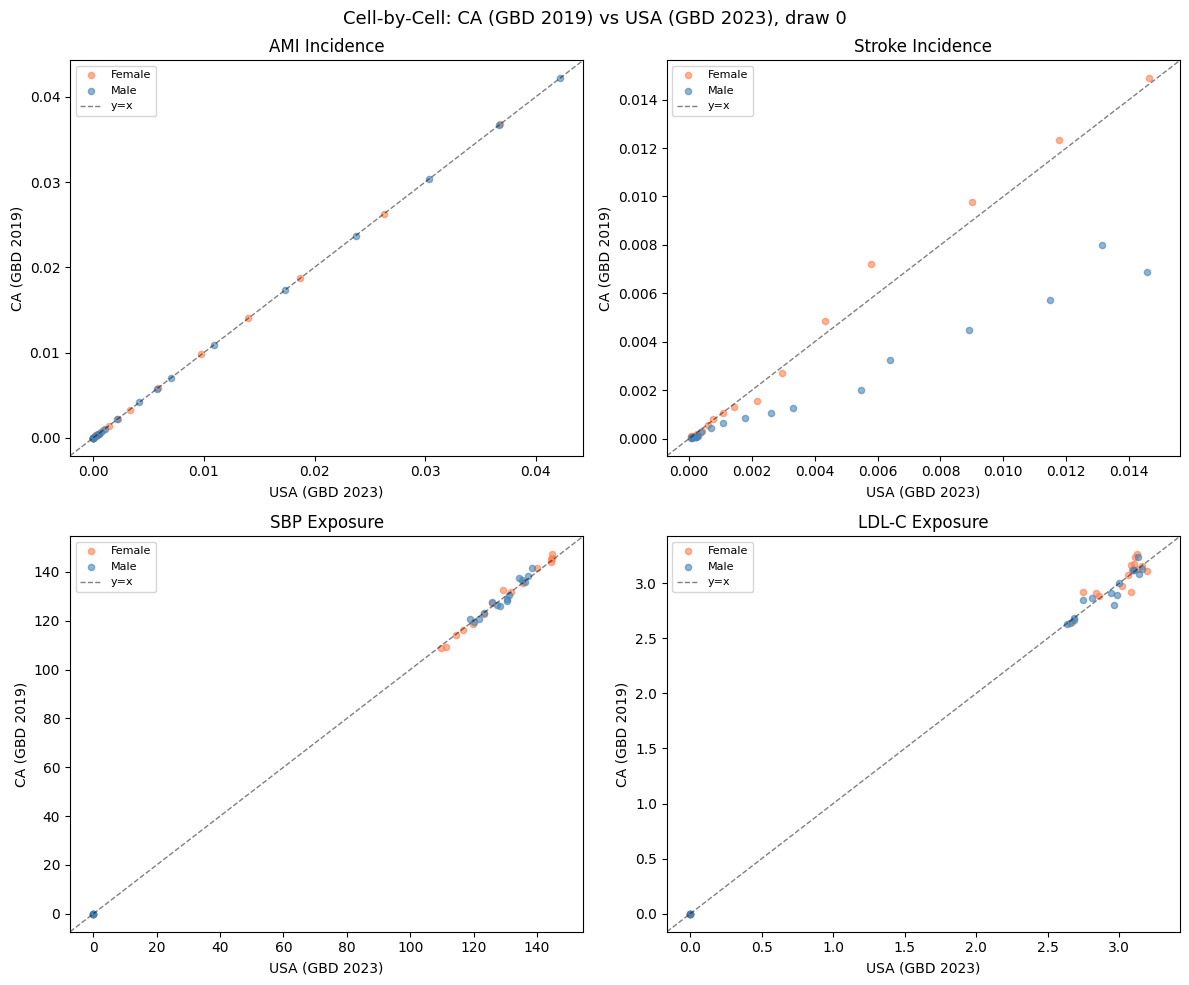

In [10]:
scatter_keys = {
    'AMI Incidence': '/cause/acute_myocardial_infarction/incidence_rate',
    'Stroke Incidence': '/cause/ischemic_stroke/incidence_rate',
    'SBP Exposure': '/risk_factor/high_systolic_blood_pressure/exposure',
    'LDL-C Exposure': '/risk_factor/high_ldl_cholesterol/exposure',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (title, key) in zip(axes.flat, scatter_keys.items()):
    ca = load_rate(CA_PATH, key)
    us = load_rate(USA_PATH, key)
    merge_cols = [c for c in ['sex', 'age_start', 'age_end']
                  if c in ca.columns and c in us.columns]
    merged = ca.merge(us, on=merge_cols, suffixes=('_ca', '_usa'))

    for sex, color in [('Female', 'coral'), ('Male', 'steelblue')]:
        sub = merged[merged['sex'] == sex]
        ax.scatter(sub['value_usa'], sub['value_ca'], alpha=0.6,
                   color=color, label=sex, s=20)

    # Perfect agreement line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='y=x')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('USA (GBD 2023)')
    ax.set_ylabel('CA (GBD 2019)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Cell-by-Cell: CA (GBD 2019) vs USA (GBD 2023), draw 0', fontsize=13)
plt.tight_layout()
plt.show()

### Draw-Level Comparison (SBP Exposure)

Compare the uncertainty bands across draws. The CA artifact has 1000
draws; the USA artifact has 250.

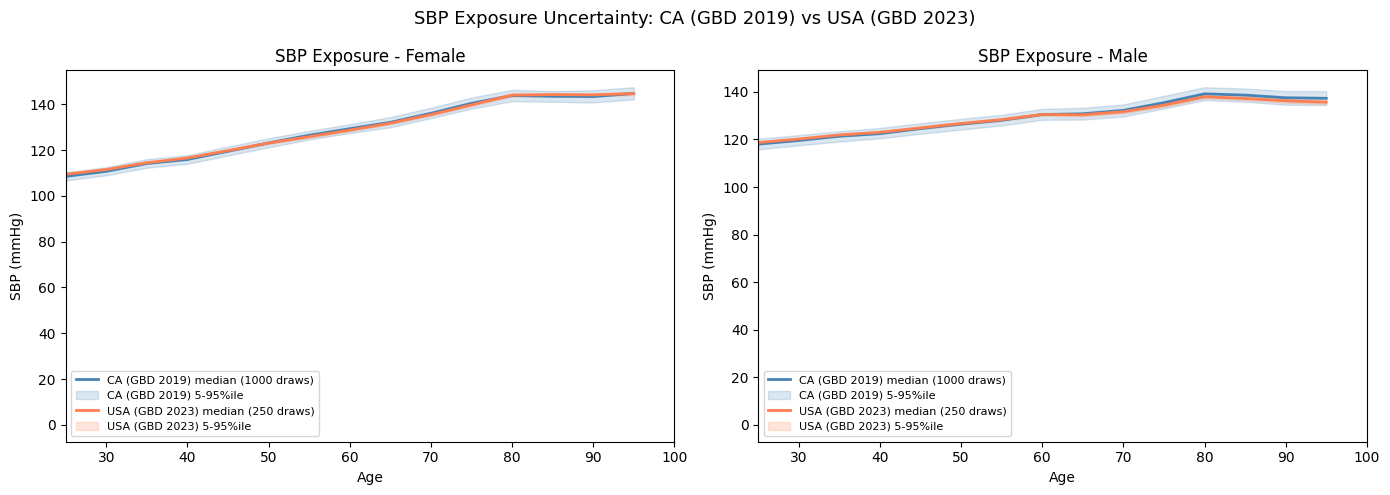

In [11]:
sbp_key = '/risk_factor/high_systolic_blood_pressure/exposure'
ca_sbp = pd.read_hdf(CA_PATH, sbp_key)
usa_sbp = pd.read_hdf(USA_PATH, sbp_key)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sex in zip(axes, ['Female', 'Male']):
    for label, df, color in [
        ('CA (GBD 2019)', ca_sbp.reset_index(), 'steelblue'),
        ('USA (GBD 2023)', usa_sbp.reset_index(), 'coral'),
    ]:
        dcols = [c for c in df.columns if c.startswith('draw_')]
        sub = df[df['sex'] == sex].sort_values('age_start')
        ages = sub['age_start'].values
        vals = sub[dcols].values
        median = np.median(vals, axis=1)
        p5 = np.percentile(vals, 5, axis=1)
        p95 = np.percentile(vals, 95, axis=1)
        ax.plot(ages, median, color=color, linewidth=2,
                label=f'{label} median ({len(dcols)} draws)')
        ax.fill_between(ages, p5, p95, alpha=0.2, color=color,
                        label=f'{label} 5-95%ile')
    ax.set_title(f'SBP Exposure - {sex}')
    ax.set_xlabel('Age')
    ax.set_ylabel('SBP (mmHg)')
    ax.legend(fontsize=8)
    ax.set_xlim(25, 100)

fig.suptitle('SBP Exposure Uncertainty: CA (GBD 2019) vs USA (GBD 2023)', fontsize=13)
plt.tight_layout()
plt.show()

### Medication Adherence Comparison

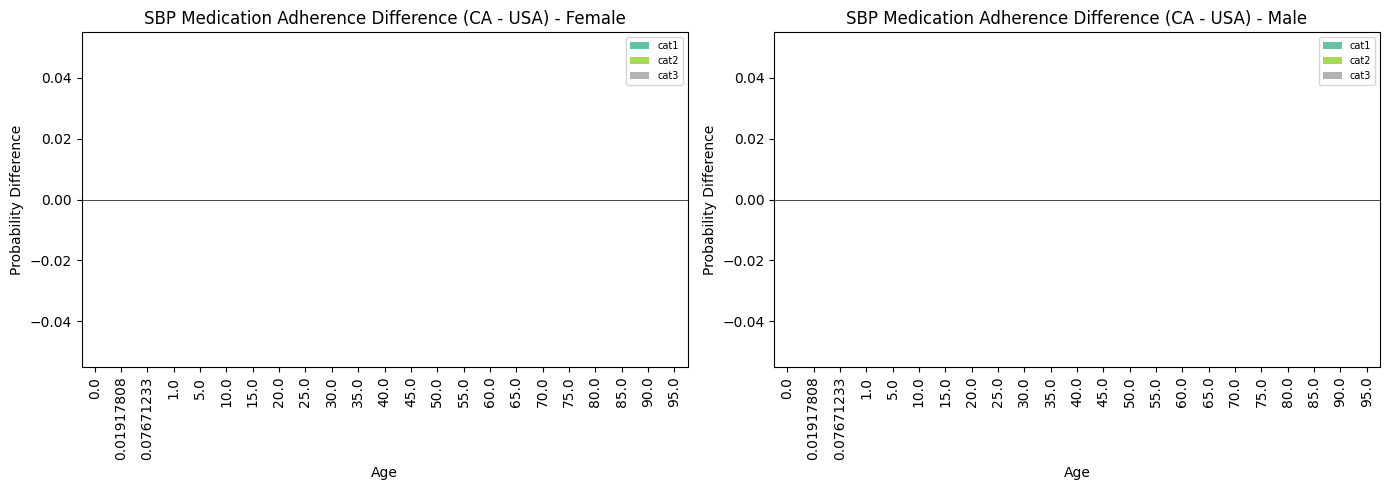

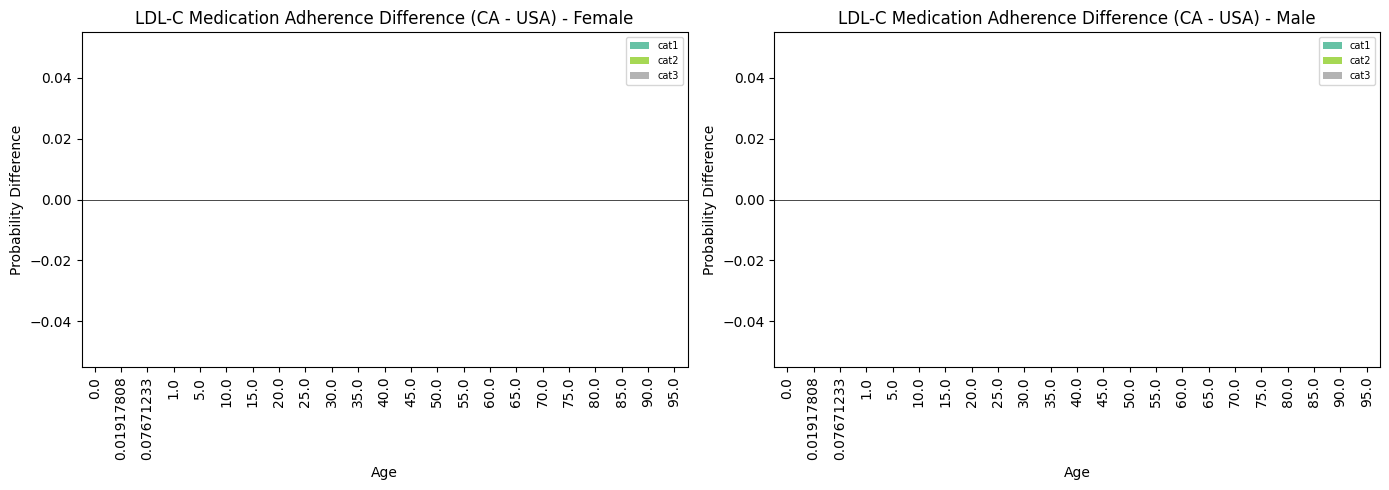

In [12]:
for title, key in [
    ('SBP Medication Adherence', '/risk_factor/sbp_medication_adherence/exposure'),
    ('LDL-C Medication Adherence', '/risk_factor/ldlc_medication_adherence/exposure'),
]:
    ca_df = pd.read_hdf(CA_PATH, key)
    ca_df = ca_df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
    usa_df = pd.read_hdf(USA_PATH, key)
    usa_df = usa_df[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()

    for df in [ca_df, usa_df]:
        for col in ['location', 'year_start', 'year_end']:
            if col in df.columns:
                df.drop(columns=[col], inplace=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, sex in zip(axes, ['Female', 'Male']):
        ca_sub = ca_df[ca_df['sex'] == sex].pivot(
            index='age_start', columns='parameter', values='value')
        usa_sub = usa_df[usa_df['sex'] == sex].pivot(
            index='age_start', columns='parameter', values='value')

        # Align on common age bins, then plot side-by-side
        common_idx = ca_sub.index.intersection(usa_sub.index)
        ca_sub = ca_sub.loc[common_idx]
        usa_sub = usa_sub.loc[common_idx]

        x = np.arange(len(common_idx))
        width = 0.35
        for i, param in enumerate(ca_sub.columns):
            ax.bar(x * len(ca_sub.columns) + i - width/2, ca_sub[param],
                   width, label=f'CA {param}', alpha=0.7)
            ax.bar(x * len(ca_sub.columns) + i + width/2, usa_sub[param],
                   width, label=f'USA {param}', alpha=0.7)

        # Simpler: just show the difference
        ax.clear()
        diff = ca_sub - usa_sub
        diff.plot.bar(ax=ax, colormap='Set2')
        ax.set_title(f'{title} Difference (CA - USA) - {sex}')
        ax.set_xlabel('Age')
        ax.set_ylabel('Probability Difference')
        ax.legend(fontsize=7)
        ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

### Full Key-by-Key Comparison

For each shared key, load only draw_0 and compute the mean absolute
relative difference across matched demographic cells. Keys with very
large tables (e.g. relative_risk with 200K+ rows) are skipped to
avoid memory issues.

In [13]:
with pd.HDFStore(str(CA_PATH), 'r') as s1, pd.HDFStore(str(USA_PATH), 'r') as s2:
    all_keys = sorted(set(s1.keys()) & set(s2.keys()))

# Keys with huge tables that would blow up memory
SKIP_KEYS = {k for k in all_keys if 'relative_risk' in k}

diffs = {}
notes = {}
for key in all_keys:
    if key in SKIP_KEYS:
        notes[key] = 'skipped (large table)'
        continue
    try:
        ca = pd.read_hdf(CA_PATH, key)
        usa = pd.read_hdf(USA_PATH, key)

        # Only compare keys that have draw columns
        if 'draw_0' not in ca.columns and 'draw_0' not in usa.columns:
            # Check for 'value' column (flat format like USA PAFs)
            if 'value' not in ca.columns and 'value' not in usa.columns:
                notes[key] = 'no draw or value columns'
                continue

        # Extract single value column
        if 'draw_0' in ca.columns:
            ca_r = ca[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
        else:
            ca_r = ca[['value']].reset_index() if 'value' in ca.columns else ca.reset_index()
        if 'draw_0' in usa.columns:
            usa_r = usa[['draw_0']].rename(columns={'draw_0': 'value'}).reset_index()
        else:
            usa_r = usa[['value']].reset_index() if 'value' in usa.columns else usa.reset_index()

        # Drop year/location so different GBD rounds can merge
        for df in [ca_r, usa_r]:
            for col in ['year_start', 'year_end', 'location']:
                if col in df.columns:
                    df.drop(columns=[col], inplace=True)

        # Merge on remaining common columns
        merge_cols = [c for c in ca_r.columns if c != 'value' and c in usa_r.columns]
        if not merge_cols:
            notes[key] = 'no common merge columns'
            continue
        merged = ca_r.merge(usa_r, on=merge_cols, suffixes=('_ca', '_usa'))
        if len(merged) == 0:
            notes[key] = 'no matching rows after merge'
            continue

        # For risk exposures, only compare ages >= 25
        if 'age_start' in merged.columns and '/risk_factor/' in key:
            merged = merged[merged['age_start'] >= 25]

        mask = merged['value_usa'] != 0
        if mask.sum() == 0:
            notes[key] = 'all USA values are zero'
            continue
        rel = np.abs((merged.loc[mask, 'value_ca'] - merged.loc[mask, 'value_usa'])
                     / merged.loc[mask, 'value_usa'])
        diffs[key] = rel.mean() * 100
    except Exception as e:
        notes[key] = f'error: {e}'

diff_series = pd.Series(diffs).sort_values(ascending=False)
print('Mean Absolute Relative Difference (%) by Key')
print('  (CA GBD 2019 vs USA GBD 2023, draw 0, ages >= 25 for risk factors)')
print('=' * 90)
for k, v in diff_series.items():
    bar = '#' * min(int(v / 2) + 1, 40) if v > 0.5 else '.'
    print(f'{k:72s} {v:8.1f}%  {bar}')
if notes:
    print(f'\nNotes ({len(notes)} keys):')
    for k, n in sorted(notes.items()):
        print(f'  {k}: {n}')

Mean Absolute Relative Difference (%) by Key
  (CA GBD 2019 vs USA GBD 2023, draw 0, ages >= 25 for risk factors)
/sequela/acute_ischemic_stroke/excess_mortality_rate                     103461.7%  ########################################
/cause/acute_myocardial_infarction/prevalence                               213.3%  ########################################
/cause/acute_myocardial_infarction_and_heart_failure/prevalence             140.5%  ########################################
/population/structure                                                        88.0%  ########################################
/cause/heart_failure_from_ischemic_heart_disease/disability_weight           71.7%  ####################################
/sequela/chronic_ischemic_stroke/excess_mortality_rate                       69.8%  ###################################
/cause/heart_failure_residual/prevalence                                     50.0%  ##########################
/cause/ischemic_stroke/cause_speci

## Discussion

### Expected differences between the two artifacts

These artifacts differ in both **location** (California vs USA) and
**GBD round** (2019 vs 2023), so substantial differences are expected
and do not indicate errors.

1. **Population structure**: California is ~12% of the US population.
   The age/sex distribution shapes should be similar but not identical.

2. **Disease rates**: State-level rates can differ meaningfully from
   national rates. Additionally, GBD methodology changes between rounds
   can shift estimates. A difference of 10-30% in many disease rates
   would be unsurprising.

3. **Risk factor exposures**: Similar reasoning — California may have
   different average SBP, LDL-C, BMI, and FPG than the US as a whole,
   and GBD 2023 estimates may differ from GBD 2019.

4. **PAFs**: The CA PAFs come from a simulation with 1000 draws; the
   USA PAFs may have a different format (e.g. single value from a
   different calculation method). Structural differences are expected.

5. **Location-independent keys**: Relative risks, TMREDs, mediation
   factors, and distributions should be similar across locations within
   the same GBD round, but may differ between GBD 2019 and GBD 2023.

6. **Known issues in USA artifact**: Some keys (AMI incidence/EMR,
   post-MI EMR/prevalence) still have year_start=2019 and 1000 draws,
   suggesting they may contain placeholder data from the old pipeline.